# Plug-and-Play DRUNet PET Reconstruction with SVRG in SIRF

* This notebook demonstrates how to integrate learned regularization components from DeepInverse into PET reconstruction workflows using SIRF.

* It implements a Plug-and-Play (PnP) reconstruction algorithm using a pretrained DRUNet denoiser as an implicit prior.

* The reconstruction uses Stochastic Variance Reduced Gradient (SVRG) for data fidelity updates combined with iterative denoising steps.

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import deepinv as dinv

import sirf.STIR as pet
from sirf.Utilities import examples_data_path

from cil.optimisation.functions import SVRGFunction
from tqdm.notebook import tqdm

## Helper functions

In [2]:
def plot_2d_image(idx, vol, title, clims=None, cmap="viridis"):
    plt.subplot(*idx)
    plt.imshow(vol, cmap=cmap)
    if clims is not None:
        plt.clim(clims)
    plt.colorbar(shrink=0.4)
    plt.title(title)
    plt.axis("off")

def make_positive(image_array):
    image_array = image_array.copy()
    image_array[image_array < 0] = 0
    return image_array

def make_cylindrical_fov(image):
    trunc = pet.TruncateToCylinderProcessor()
    trunc.apply(image)

## Set up the reconstruction problem

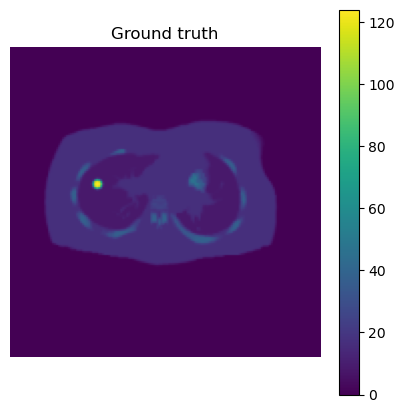

In [3]:
data_path = os.path.join(examples_data_path('PET'), 'thorax_single_slice')
msg_red = pet.MessageRedirector('info.txt', 'warnings.txt', 'errors.txt')

#image = pet.ImageData(os.path.join(data_path, 'emission.hv')) * 0.4
image = pet.ImageData(os.path.join(data_path, 'emission.hv')) * 2.0
attn_image = pet.ImageData(os.path.join(data_path, 'attenuation.hv'))
template = pet.AcquisitionData(os.path.join(data_path, 'template_sinogram.hs'))

cmax = image.max() * 0.6
im_slice = image.dimensions()[0] // 2

acq_model_for_attn = pet.AcquisitionModelUsingRayTracingMatrix()
asm_attn = pet.AcquisitionSensitivityModel(attn_image, acq_model_for_attn)
asm_attn.set_up(template)

attn_factors = asm_attn.forward(template.get_uniform_copy(1))
asm_attn = pet.AcquisitionSensitivityModel(attn_factors)

acq_model = pet.AcquisitionModelUsingRayTracingMatrix()
acq_model.set_num_tangential_LORs(5)
# acq_model.set_acquisition_sensitivity(asm_attn)
acq_model.set_up(template, image)

plt.figure(figsize=(5, 5))
plt.imshow(image.as_array()[im_slice, :, :], cmap="viridis")
plt.colorbar()
plt.title("Ground truth")
plt.axis("off")
plt.show()

## Simulate acquisition data

In [4]:
acquired_data_clean = acq_model.forward(image)

acq_arr = acquired_data_clean.as_array().astype(np.float32)
acq_arr_noisy = np.random.poisson(acq_arr).astype(np.float32)

acquired_data = acquired_data_clean.clone()
acquired_data.fill(acq_arr_noisy)

obj_fun = pet.make_Poisson_loglikelihood(acquired_data)
obj_fun.set_acquisition_model(acq_model)

## Baseline reconstruction: OSMAPOSL

In [5]:
recon = pet.OSMAPOSLReconstructor()
recon.set_num_subsets(4)

initial_image = image.get_uniform_copy(cmax / 4)
make_cylindrical_fov(initial_image)

im_slice = initial_image.dimensions()[0] // 2

### OSMAPOSL (no prior)

In [6]:
num_subiters = 100

obj_fun_no_prior = pet.make_Poisson_loglikelihood(acquired_data)
obj_fun_no_prior.set_acquisition_model(acq_model)

In [7]:
recon.set_objective_function(obj_fun_no_prior)
recon.set_num_subiterations(num_subiters)
recon.set_up(initial_image)
recon.set_current_estimate(initial_image)
recon.process()

reconstructed_image_no_prior = recon.get_output()

### OSMAPOSL + RDP

In [8]:
prior = pet.RelativeDifferencePrior()
prior.set_penalisation_factor(0.3)
prior.set_gamma(2.0)
prior.set_epsilon(1e-3)
prior.set_kappa(initial_image.get_uniform_copy(1.0))

obj_fun_rdp = pet.make_Poisson_loglikelihood(acquired_data)
obj_fun_rdp.set_acquisition_model(acq_model)
obj_fun_rdp.set_prior(prior)

In [9]:
recon.set_objective_function(obj_fun_rdp)
recon.set_num_subiterations(num_subiters)
recon.set_up(initial_image)
recon.set_current_estimate(initial_image)
recon.process()

reconstructed_image_rdp = recon.get_output()

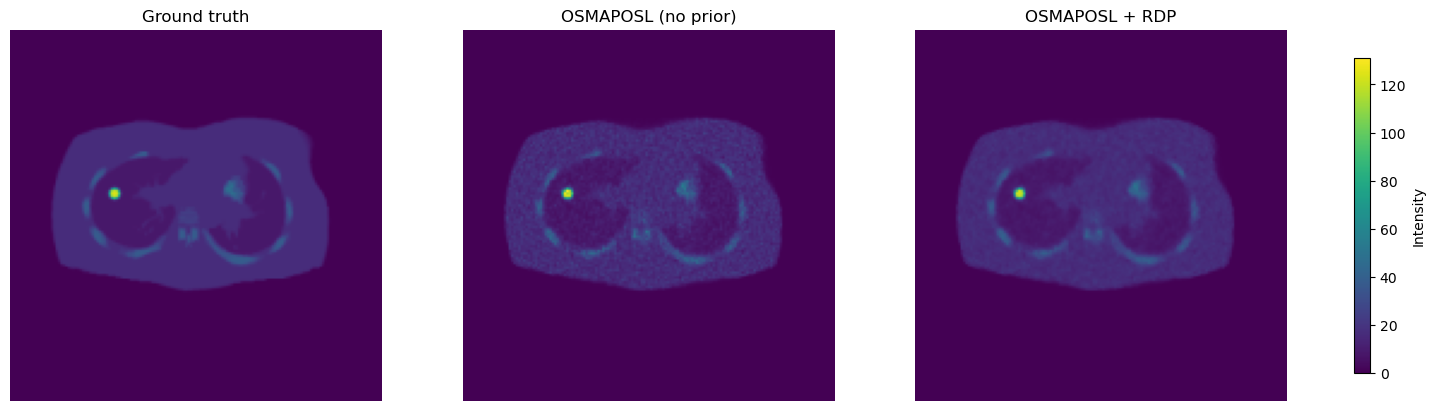

In [10]:
gt_slice = image.as_array()[im_slice, :, :]
no_prior_slice = reconstructed_image_no_prior.as_array()[im_slice, :, :]
rdp_slice = reconstructed_image_rdp.as_array()[im_slice, :, :]

vmin = 0.0
vmax = max(gt_slice.max(), no_prior_slice.max(), rdp_slice.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im0 = axes[0].imshow(gt_slice, cmap="viridis", vmin=vmin, vmax=vmax)
axes[0].set_title("Ground truth")
axes[0].axis("off")

im1 = axes[1].imshow(no_prior_slice, cmap="viridis", vmin=vmin, vmax=vmax)
axes[1].set_title("OSMAPOSL (no prior)")
axes[1].axis("off")

im2 = axes[2].imshow(rdp_slice, cmap="viridis", vmin=vmin, vmax=vmax)
axes[2].set_title("OSMAPOSL + RDP")
axes[2].axis("off")

cbar = fig.colorbar(im2, ax=axes, shrink=0.85)
cbar.set_label("Intensity")

plt.show()

## Learned denoising with DRUNet

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

denoiser = dinv.models.DRUNet(
    in_channels=1,
    out_channels=1,
    pretrained="download"
).to(device)

denoiser.eval()

Device: cpu


DRUNet(
  (m_head): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (m_down1): Sequential(
    (0): ResBlock(
      (res): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
    )
    (1): ResBlock(
      (res): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
    )
    (2): ResBlock(
      (res): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
    )
    (3): ResBlock(
      (res): Sequential(
        (0): Conv2

### Single-step DRUNet denoising on OSMAPOSL (no prior)

In [12]:
slice_no_prior = reconstructed_image_no_prior.as_array()[im_slice, :, :].astype(np.float32)

smin = slice_no_prior.min()
smax = slice_no_prior.max()
slice_norm = (slice_no_prior - smin) / (smax - smin + 1e-8)

x = torch.tensor(slice_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    x_denoised = denoiser(x, sigma=0.05)

slice_denoised = x_denoised.squeeze().detach().cpu().numpy()
slice_denoised = slice_denoised * (smax - smin) + smin

### Slice-wise DRUNet denoising helper

In [13]:
def drunet_denoise_volume_2p5d(vol3d, denoiser, device, sigma=0.05):
    vol_out = np.zeros_like(vol3d, dtype=np.float32)

    for z in range(vol3d.shape[0]):
        slice2d = vol3d[z, :, :].astype(np.float32)

        smin = slice2d.min()
        smax = slice2d.max()
        slice2d_norm = (slice2d - smin) / (smax - smin + 1e-8)

        x = torch.tensor(slice2d_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            x_denoised = denoiser(x, sigma=sigma)

        out = x_denoised.squeeze().detach().cpu().numpy()
        out = out * (smax - smin) + smin
        vol_out[z, :, :] = out

    return vol_out

## SVRG-based Plug-and-Play reconstruction

### SVRG setup

In [14]:
eps = 1e-6
num_subsets = 4

ones_acq = acquired_data.get_uniform_copy(1.0)
sens_img = acq_model.backward(ones_acq)
sens_arr = sens_img.as_array().astype(np.float32)

In [15]:
class STIRSubsetFunction:
    def __init__(self, obj_fun, subset_idx):
        self.obj_fun = obj_fun
        self.subset_idx = subset_idx

    def __call__(self, x):
        return self.obj_fun.value(x)

    def gradient(self, x, out=None):
        g = self.obj_fun.gradient(x, self.subset_idx)
        if out is not None:
            out.fill(g)
            return out
        return g

In [16]:
obj_fun_no_prior.set_up(initial_image)
subset_functions = [STIRSubsetFunction(obj_fun_no_prior, s) for s in range(num_subsets)]

svrg_obj = SVRGFunction(
    subset_functions,
    snapshot_update_interval=num_subsets
)

### SVRG update step

In [17]:
def cil_svrg_step(current_image, alpha=1.0):
    x_arr = current_image.as_array().astype(np.float32)

    grad_img = svrg_obj.gradient(current_image)
    grad_arr = grad_img.as_array().astype(np.float32)

    P = x_arr / (sens_arr + eps)

    x_new = x_arr + alpha * P * grad_arr
    x_new[x_new < 0] = 0

    out = current_image.clone()
    out.fill(x_new)
    make_cylindrical_fov(out)
    return out

## Run the algorithm (PnP reconstruction loop)

In [18]:
num_pnp_iters = 100
#sigma_denoiser = 3.0 / 255.0
sigma_denoiser = 1.0 / 255.0

alpha = 0.2
#lam = 0.35
lam = 0.35

current_image = initial_image.clone()
obj_fun_no_prior.set_up(current_image)

pnp_objective_values = [obj_fun_no_prior.value(current_image)]

all_pnp_images = np.ndarray(
    shape=(num_pnp_iters + 1,) + current_image.as_array().shape,
    dtype=np.float32
)
all_pnp_images[0] = current_image.as_array()

In [19]:
for i in range(1, num_pnp_iters + 1):
    current_image = cil_svrg_step(current_image, alpha=alpha)
    
    # DRUNet denoising every 50 iterations
    if i % 10 == 0:
        vol = current_image.as_array().astype(np.float32)
        vol_denoised = drunet_denoise_volume_2p5d(
            vol, denoiser, device, sigma=sigma_denoiser
        )

         # soft blending to reduce oversmoothing
        vol = (1 - lam) * vol + lam * vol_denoised
        vol = make_positive(vol)

        current_image.fill(vol)
        make_cylindrical_fov(current_image)

    pnp_objective_values.append(obj_fun_no_prior.value(current_image))
    all_pnp_images[i] = current_image.as_array()

## Comparison of reconstruction methods

We compare different reconstruction strategies:

* **OSMAPOSL (no prior)**: Standard iterative reconstruction without regularization  
* **OSMAPOSL + RDP**: Reconstruction with Relative Difference Prior (classical regularization)  
* **DRUNet (single-step, no prior)**: Post-processing denoising applied once to OSMAPOSL (no prior) output 
* **PnP (SVRG + DRUNet)**: Iterative Plug-and-Play reconstruction combining SVRG data consistency with DRUNet denoising  

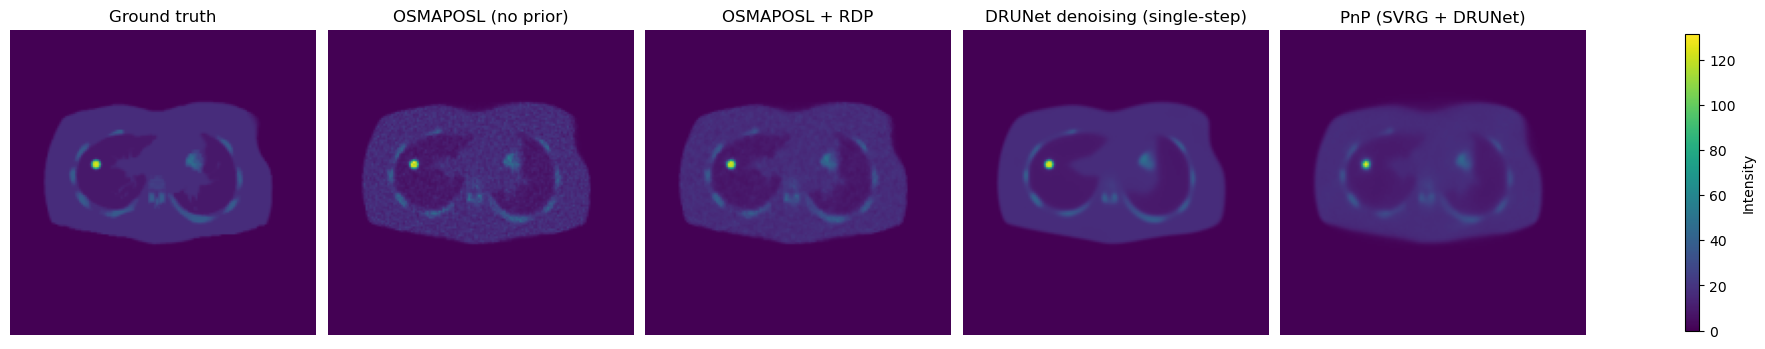

In [20]:
gt_slice = image.as_array()[im_slice, :, :]
no_prior_slice = reconstructed_image_no_prior.as_array()[im_slice, :, :]
rdp_slice = reconstructed_image_rdp.as_array()[im_slice, :, :]
drunet_once_slice = slice_denoised 
final_pnp = all_pnp_images[-1, im_slice, :, :]

plt.figure(figsize=(20,4))

plt.subplot(1,5,1)
plt.imshow(gt_slice, cmap="viridis", vmin=vmin, vmax=vmax)
plt.title("Ground truth")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(no_prior_slice, cmap="viridis", vmin=vmin, vmax=vmax)
plt.title("OSMAPOSL (no prior)")
plt.axis("off")

plt.subplot(1,5,3)
plt.imshow(rdp_slice, cmap="viridis", vmin=vmin, vmax=vmax)
plt.title("OSMAPOSL + RDP")
plt.axis("off")

plt.subplot(1,5,4)
plt.imshow(drunet_once_slice, cmap="viridis", vmin=vmin, vmax=vmax)
plt.title("DRUNet denoising (single-step)")
plt.axis("off")

plt.subplot(1,5,5)
plt.imshow(final_pnp, cmap="viridis", vmin=vmin, vmax=vmax)
plt.title("PnP (SVRG + DRUNet)")
plt.axis("off")

plt.tight_layout()
cbar = plt.colorbar(ax=plt.gcf().axes, shrink=0.8)
cbar.set_label("Intensity")
plt.show()